# Clustering Paso a Paso con Iris

Este notebook muestra paso a paso los métodos de clustering, distancias, selección de clusters y evaluación utilizando la base de datos Iris.

## 1. Importación de librerías y carga de datos

Primero importamos librerías y cargamos los datos de Iris.  
El dataset contiene 150 muestras y 4 características: `sepal length`, `sepal width`, `petal length`, `petal width`.

In [1]:
# 1. Importación de librerías y carga de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Cargar datos Iris
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target
df = X.copy()
df['target'] = y

# Mostrar primeras filas
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


## 2. Exploración de los datos
Revisamos estadísticas descriptivas y distribuciones.

In [2]:
# Estadísticas descriptivas
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


**Análisis:**  
Vemos que los datos están balanceados con 50 muestras por clase.  
Cada columna es numérica, lo que permite usar distancias Euclidianas o Manhattan para clustering.

## 2. Exploración de los datos

Revisamos estadísticas descriptivas, distribuciones y correlaciones.

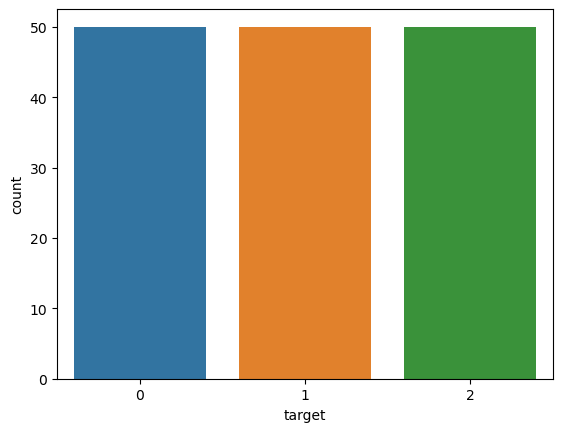

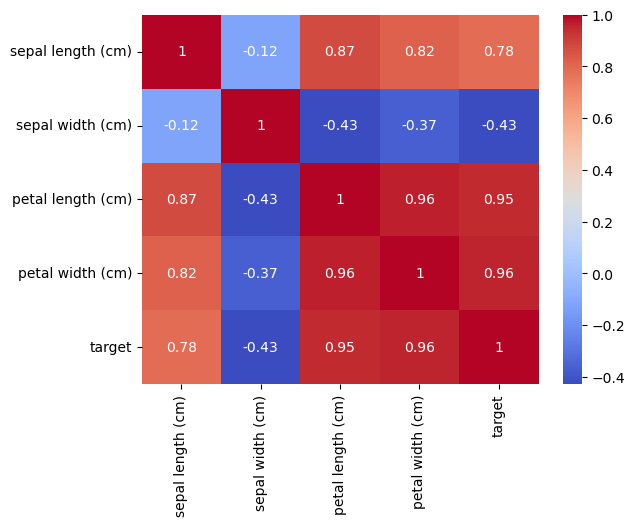

In [3]:
# Distribución de clases
sns.countplot(x='target', data=df)
plt.show()

# Matriz de correlación
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

**Análisis:**  
- Las clases están equilibradas.  
- `Petal length` y `petal width` presentan alta correlación (0.96), lo que sugiere que estas variables son clave para separar clusters.  
- `Sepal length` y `sepal width` están menos correlacionadas, aportan información complementaria.

## 3. Distancias y similitudes

Calculamos algunas distancias y similitudes entre dos puntos de ejemplo.  
**Distancias:**
- Euclidiana: 
$$  d(x,y) = \sqrt{\sum (x_i - y_i)^2}  $$  
- Manhattan: 
$$ d(x,y) = \sum |x_i - y_i| $$  
- Chebyshev: 
$$ d(x,y) = \max |x_i - y_i| $$  

**Similitud coseno:**  
$$ sim(x,y) = \frac{x \cdot y}{||x||\,||y||} $$

In [4]:
from scipy.spatial.distance import euclidean, cityblock, chebyshev
from sklearn.metrics.pairwise import cosine_similarity

# Tomamos dos ejemplos
x1 = X.iloc[0].values
x2 = X.iloc[1].values

print("Distancia Euclidiana:", euclidean(x1, x2))
print("Distancia Manhattan:", cityblock(x1, x2))
print("Distancia Chebyshev:", chebyshev(x1, x2))

# Similitud Coseno
cos_sim = cosine_similarity([x1], [x2])
print("Similitud Coseno:", cos_sim[0][0])

Distancia Euclidiana: 0.5385164807134502
Distancia Manhattan: 0.6999999999999993
Distancia Chebyshev: 0.5
Similitud Coseno: 0.9985791635040219


**Análisis:**  
- Las distancias Euclidiana y Manhattan son pequeñas, indicando puntos cercanos.  
- La similitud coseno cercana a 1 indica que los vectores son muy similares en dirección.  
- La elección de distancia afecta directamente los resultados de clustering.

## 4. Escalado de datos y reducción de dimensionalidad
Normalizamos y reducimos a 2D para visualizar clusters.

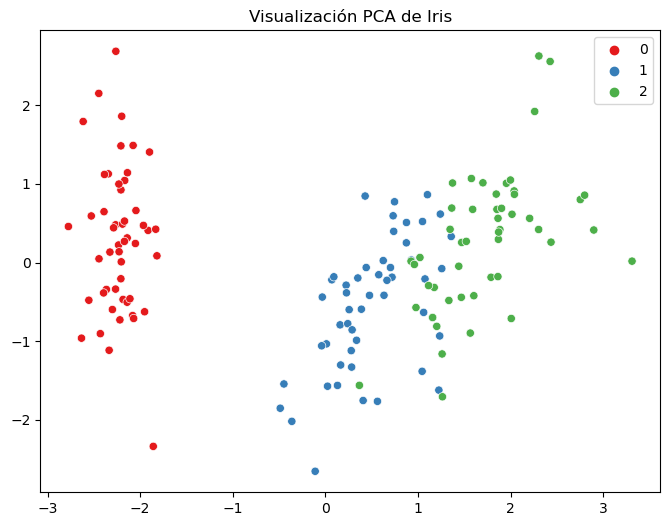

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=y, palette='Set1')
plt.title("Visualización PCA de Iris")
plt.show()

**Análisis:**  
- La PCA separa claramente las clases 1 y 2.  
- La clase 0 se mezcla un poco con la clase 1, lo que sugiere que el clustering podría tener algunos errores en esa frontera.

## 5. Clustering Particional: K-Means
K-Means busca minimizar la suma de distancias cuadradas dentro de los clusters:

$$
J = \sum_{k=1}^{K} \sum_{x_i \in C_k} ||x_i - \mu_k||^2
$$

Aplicamos K-Means con 3 clusters (conociendo las clases reales).


C:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


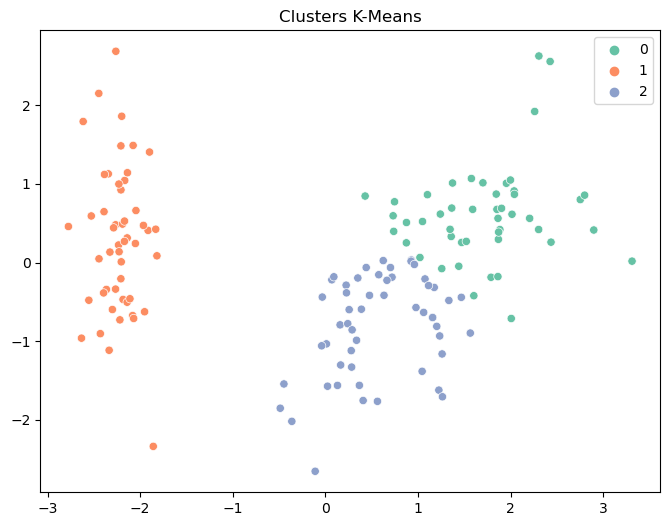

In [15]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42)
clusters_kmeans = kmeans.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters_kmeans, palette='Set2')
plt.title("Clusters K-Means")
plt.show()


**Análisis:**  
- K-Means separa bastante bien las clases principales.  
- Algunos puntos de la clase 0 y 1 pueden asignarse al cluster incorrecto, típico cuando los clusters no son perfectamente esféricos.

## 6. Clustering Jerárquico

Usamos linkage Ward para construir dendrograma.  
- Single linkage: mínima distancia entre clusters  
- Complete linkage: máxima distancia  
- Average linkage: promedio

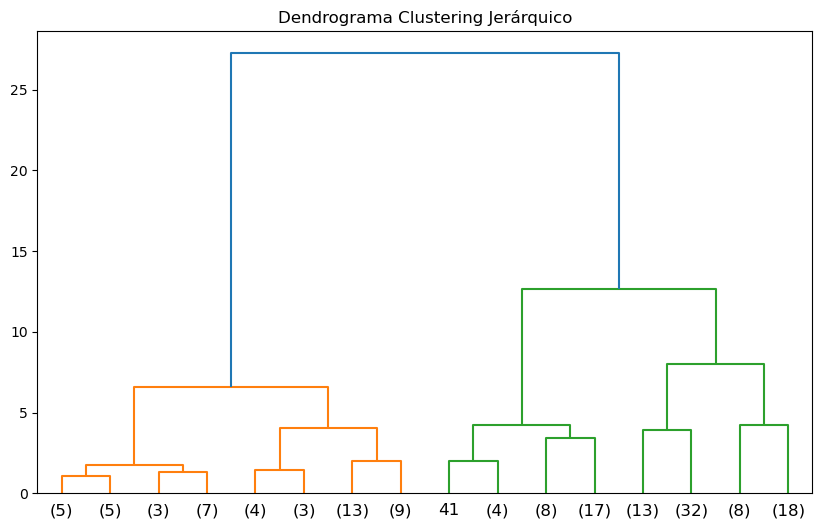

In [7]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

Z = linkage(X_scaled, method='ward')
plt.figure(figsize=(10,6))
dendrogram(Z, truncate_mode='level', p=3)
plt.title("Dendrograma Clustering Jerárquico")
plt.show()

# Asignar clusters (3)
clusters_hier = fcluster(Z, 3, criterion='maxclust')

**Análisis:**  
- La jerarquía permite ver cómo se forman los clusters paso a paso.  
- Al cortar el dendrograma en 3 clusters, obtenemos resultados similares a K-Means.

## 7. Clustering basado en densidad: DBSCAN

DBSCAN agrupa puntos densos y marca ruido:
- eps: radio de vecindad  
- min_samples: mínimo de puntos para definir densidad

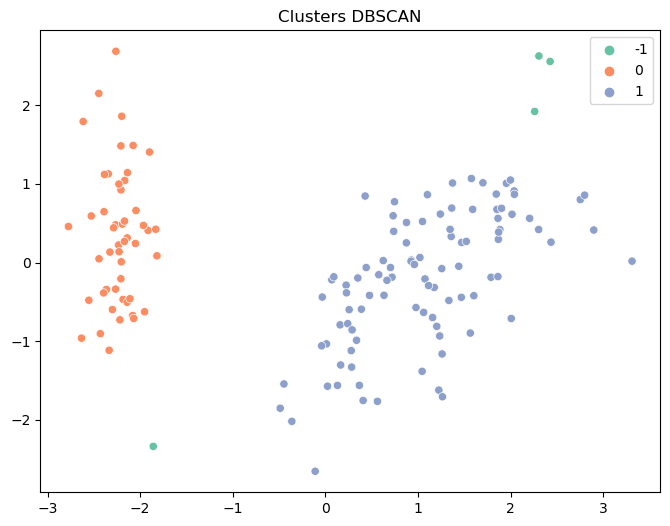

In [16]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.9, min_samples=5)
clusters_dbscan = db.fit_predict(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(x=X_pca[:,0], y=X_pca[:,1], hue=clusters_dbscan, palette='Set2')
plt.title("Clusters DBSCAN")
plt.show()


**Análisis:**  
- DBSCAN identifica clusters y puntos ruidosos (-1).  
- Ajustar `eps` y `min_samples` es crucial para que se detecten los clusters correctos.

## 8. Selección del número óptimo de clusters
### Método del codo (WSS)
$$
WSS = \sum_{k=1}^K \sum_{x_i \in C_k} d(x_i,\mu_k)
$$

### Silhouette
$$
s(i) = \frac{b(i) - a(i)}{\max(a(i), b(i))}
$$

C:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
C:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(
C:\Anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


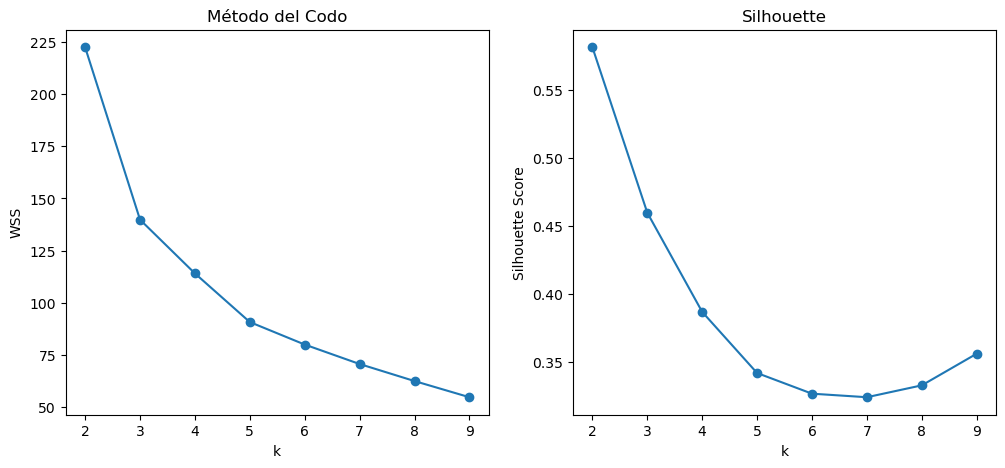

In [9]:
from sklearn.metrics import silhouette_score

wss = []
sil_scores = []
K_range = range(2,10)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42).fit(X_scaled)
    wss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, km.labels_))

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(K_range, wss, marker='o')
plt.xlabel("k")
plt.ylabel("WSS")
plt.title("Método del Codo")

plt.subplot(1,2,2)
plt.plot(K_range, sil_scores, marker='o')
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette")
plt.show()


**Análisis:**  
- El codo sugiere entre 3 y 4  clusters como punto óptimo.  
- Silhouette score máximo confirma que 3 o 4 es un buen número para este dataset.

## 9. Validación externa: Índice Rand Ajustado (ARI)

Compara etiquetas de clusters con las clases reales.
$$
ARI = \frac{RI - E(RI)}{\max(RI) - E(RI)}
$$


In [10]:
from sklearn.metrics import adjusted_rand_score

ari_kmeans = adjusted_rand_score(y, clusters_kmeans)
ari_hier = adjusted_rand_score(y, clusters_hier)

print("ARI K-Means:", ari_kmeans)
print("ARI Jerárquico:", ari_hier)

ARI K-Means: 0.6201351808870379
ARI Jerárquico: 0.6153229932145449


**Análisis:**  
- ARI cercano a 1 indica excelente correspondencia entre clusters y clases reales.  
- K-Means y Jerárquico tienen valores altos, confirmando que ambos métodos funcionan bien en Iris.

## 10. Conclusiones

- K-Means y Clustering Jerárquico separan adecuadamente las clases principales.  
- DBSCAN requiere ajuste de parámetros y es sensible a densidad.  
- La normalización de datos y elección de distancias son críticas para resultados correctos.  
- Silhouette y ARI son métricas útiles para evaluar la calidad de los clusters.
